In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ROOT = Path.cwd().parent.resolve()
RAW_DATA_DIR = ROOT / "data" / "raw"
ENTROPY_DATA_DIR = RAW_DATA_DIR / "entropydata"
entropy_file1 = ENTROPY_DATA_DIR / "EntropyCoeff_T40iT05_B0047C.csv"
entropy_file2 = ENTROPY_DATA_DIR / "EntropyCoeff_T40iT05_B0056C.csv"
entropy_file3 = ENTROPY_DATA_DIR / "EntropyCoeff_T40iT05_B0057C.csv"
entropy_file4 = ENTROPY_DATA_DIR / "EntropyCoeff_T40iT05_B0058C.csv"

entropy_df1 = pd.read_csv(entropy_file1)
entropy_df2 = pd.read_csv(entropy_file2)
entropy_df3 = pd.read_csv(entropy_file3)
entropy_df4 = pd.read_csv(entropy_file4)

In [3]:
# first, look a the columns:

print(entropy_df1.columns)

Index(['100', '0.00014588'], dtype='object')


In [6]:
# okay so they have no columns. Will assume it is SOC and entropic coefficient. Let's add them.
entropy_df1.columns = ["SOC", "Entropic_Coefficient"]
entropy_df2.columns = ["SOC", "Entropic_Coefficient"]
entropy_df3.columns = ["SOC", "Entropic_Coefficient"]
entropy_df4.columns = ["SOC", "Entropic_Coefficient"]


In [7]:
print(entropy_df1.head())

   SOC  Entropic_Coefficient
0   96              0.000127
1   92              0.000116
2   88              0.000101
3   84              0.000089
4   80              0.000075


In [8]:
# rescale the soc to be a percentage
entropy_df1["SOC"] /= 100
entropy_df2["SOC"] /= 100
entropy_df3["SOC"] /= 100
entropy_df4["SOC"] /= 100

Text(0.5, 1.0, 'Entropic Coefficient vs SOC for Different Cells')

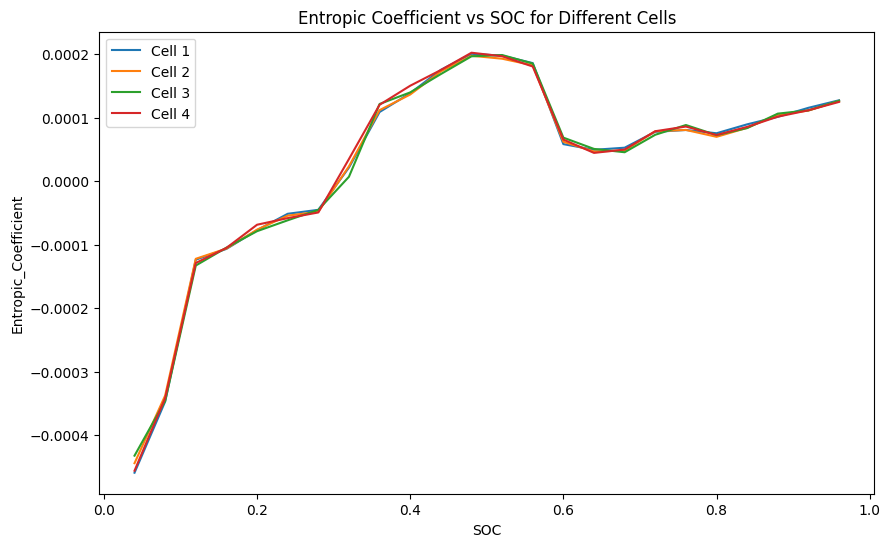

In [9]:
# now plot them all on the same figure to see the variability between the different cells. Use a different color for each cell.
plt.figure(figsize=(10, 6))
sns.lineplot(data=entropy_df1, x="SOC", y="Entropic_Coefficient", label="Cell 1")
sns.lineplot(data=entropy_df2, x="SOC", y="Entropic_Coefficient", label="Cell 2")
sns.lineplot(data=entropy_df3, x="SOC", y="Entropic_Coefficient", label="Cell 3")
sns.lineplot(data=entropy_df4, x="SOC", y="Entropic_Coefficient", label="Cell 4")
plt.title("Entropic Coefficient vs SOC for Different Cells")

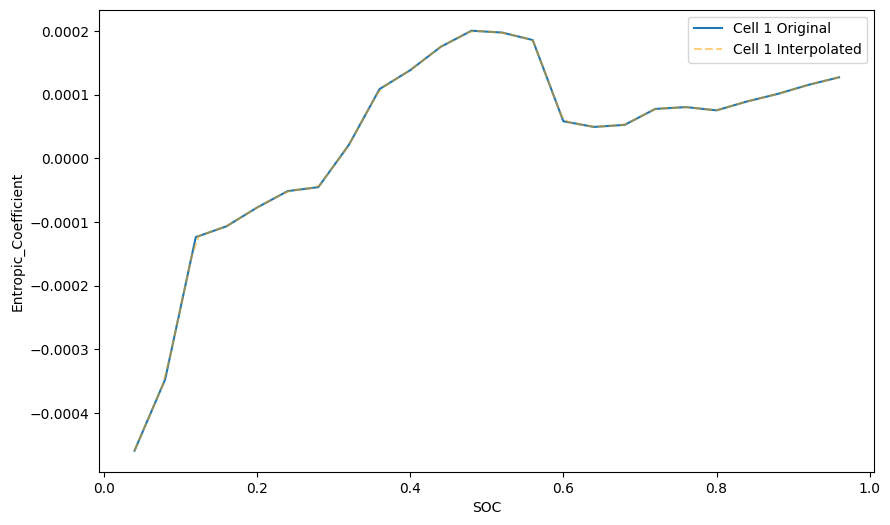

In [13]:
# they are all taken at even intervals of SOC, we will just take that of cell 1.
# finally, check the interpolated line fits well

# create interpolated function for each cell
from scipy.interpolate import interp1d

entr_func = interp1d(entropy_df1["SOC"], entropy_df1["Entropic_Coefficient"], kind="linear", fill_value="extrapolate")

socs = np.linspace(entropy_df1["SOC"].min(), entropy_df1["SOC"].max(), 100)
# plot the interpolated function against the original data
plt.figure(figsize=(10, 6))
sns.lineplot(data=entropy_df1, x="SOC", y="Entropic_Coefficient", label="Cell 1 Original")
plt.plot(socs, entr_func(socs), label="Cell 1 Interpolated", color="orange", alpha=0.5, linestyle="--")

plt.legend()

In [14]:
# nice, almost an exact match. Will save this df in the processed data dir.
processed_data_dir = ROOT / "data" / "processed"
entropy_df1.to_csv(processed_data_dir / "entropydata_cell1.csv", index=False)